THE INTERNET HAS A MEMORY

Total observations : 6,000
Historical world   : 3,000
New world          : 3,000
Hidden shift day   : 3000

RELATIONSHIP DRIFT


,Feature,Historical Correlation,Current Correlation,Relationship Change,Knowledge Expiration Score
1,discount,0.287,0.171,0.116,11.6
0,price,-0.105,-0.078,0.026,2.6
2,marketing,0.018,0.007,0.011,1.1
3,website_visits,0.242,0.236,0.005,0.5




MODEL PERFORMANCE
Historical R² : 0.420
Current R²    : -0.265
Performance loss : 0.685


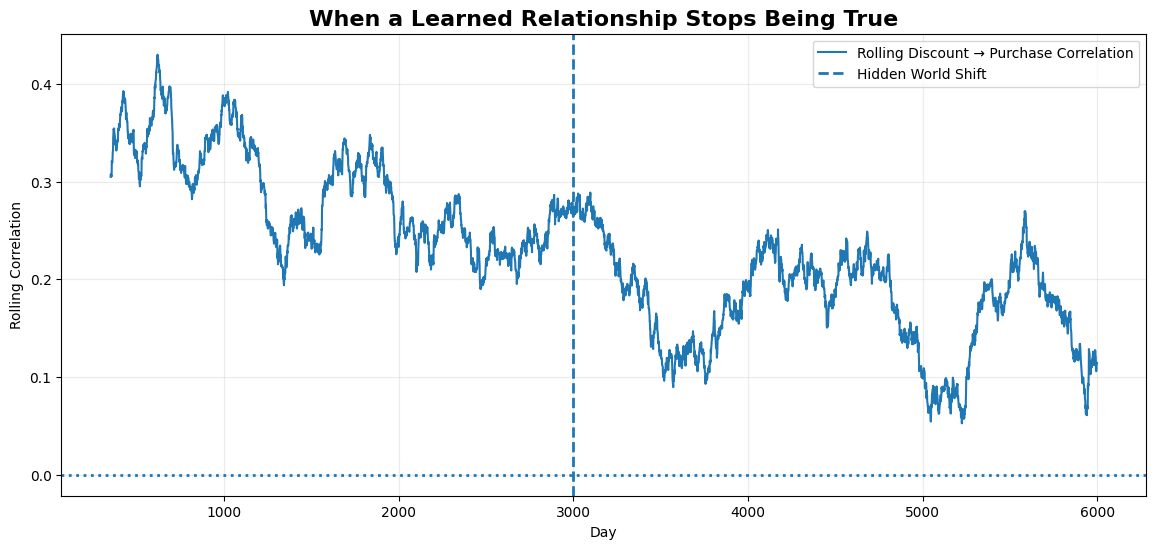

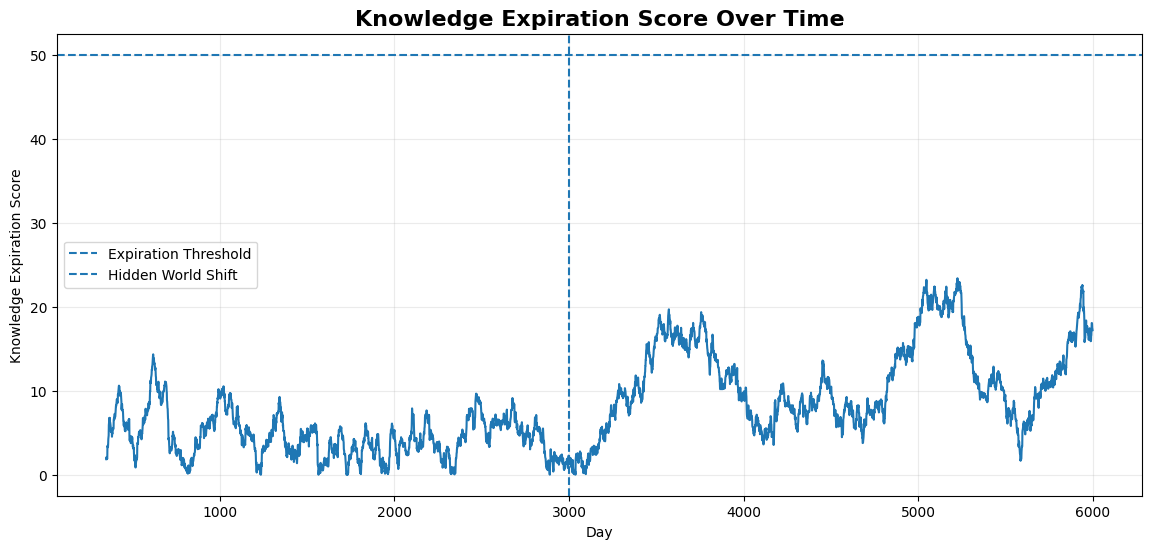

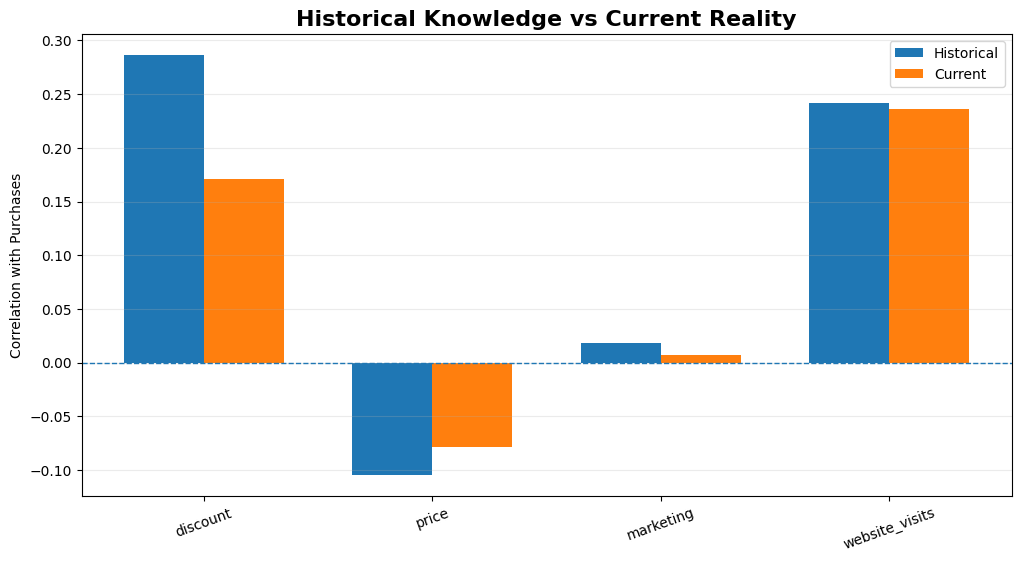

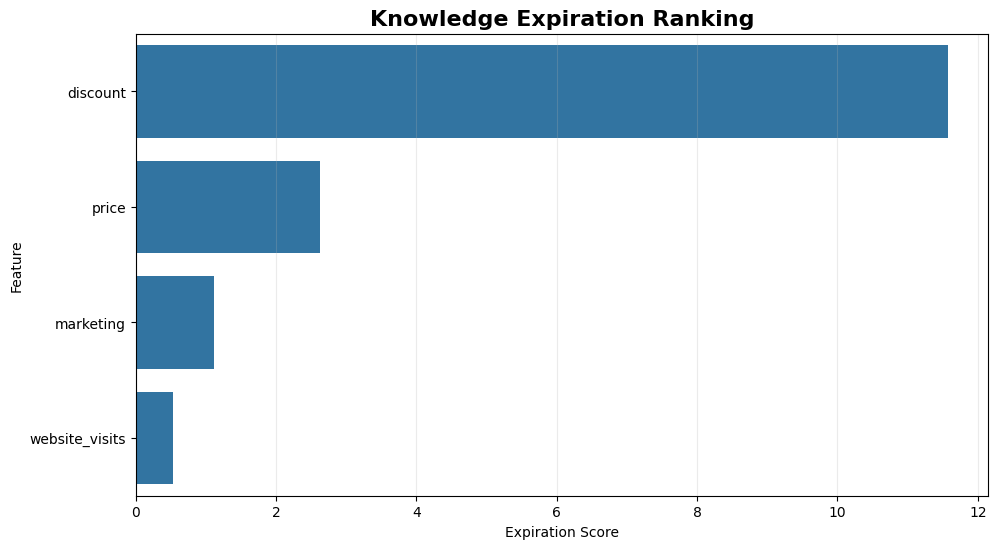

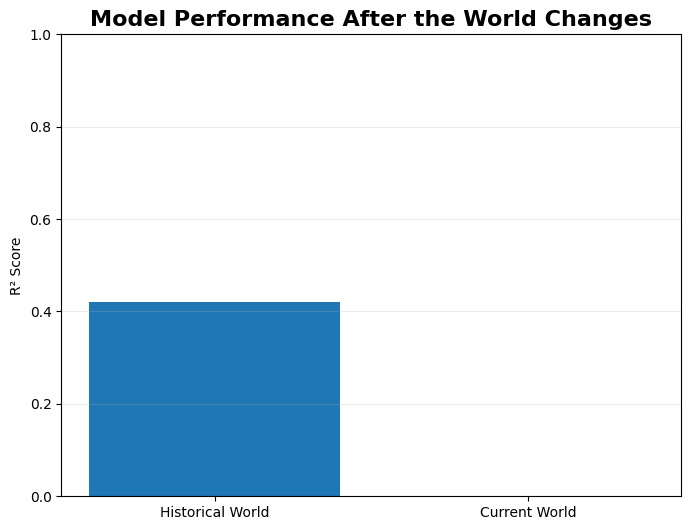

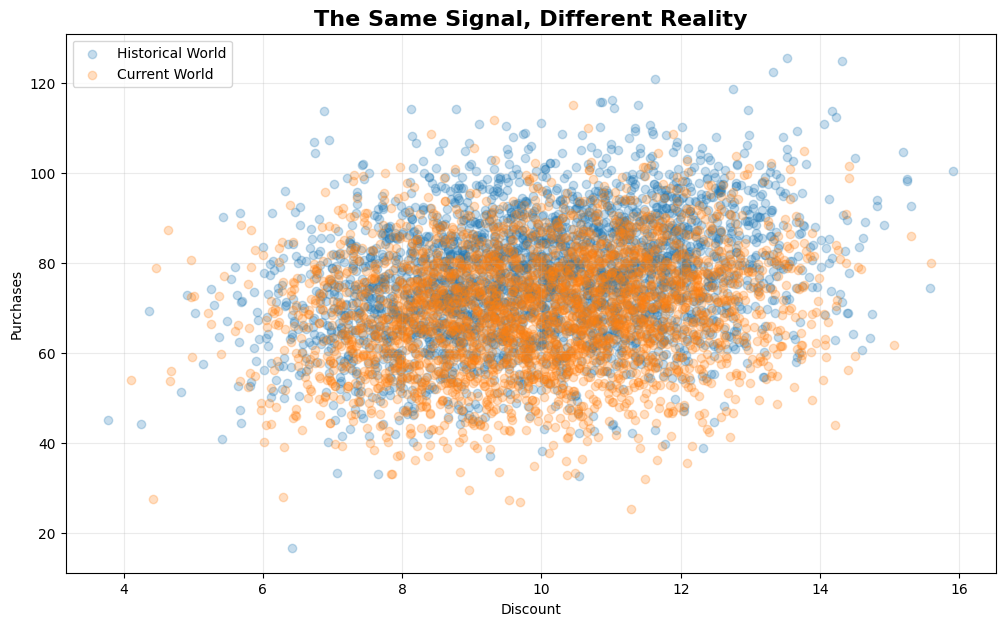



AI KNOWLEDGE EXPIRATION REPORT

Most unstable relationship:
    discount → Purchases

Historical relationship:
    0.287

Current relationship:
    0.171

Knowledge expiration score:
    11.6/100

Historical model R²:
    0.420

Current-world model R²:
    -0.265

Interpretation:
    The data distribution can remain relatively familiar while
    the relationships learned by the model change.

    This means conventional data-drift monitoring alone may
    miss an important form of model decay.

Core lesson:
    A machine-learning model does not only learn data.
    It learns relationships.

    When those relationships change,
    yesterday's knowledge can become today's mistake.



In [1]:
# ================================================================
# THE INTERNET HAS A MEMORY
# Detecting When Machine Learning Knowledge Expires
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, wasserstein_distance
from IPython.display import display

np.random.seed(42)

# ------------------------------------------------
# 1. CREATE A SYNTHETIC "LIVING" WORLD
# ------------------------------------------------

N = 6000
days = np.arange(N)

df = pd.DataFrame({
    "day": days
})

# Time-dependent variables
df["price"] = (
    100
    + 8*np.sin(days/30)
    + np.random.normal(0, 4, N)
)

df["discount"] = (
    10
    + 2*np.sin(days/17)
    + np.random.normal(0, 1.2, N)
)

df["marketing"] = (
    50
    + 10*np.sin(days/45)
    + np.random.normal(0, 5, N)
)

df["website_visits"] = (
    1000
    + 120*np.sin(days/25)
    + np.random.normal(0, 60, N)
)

# ------------------------------------------------
# 2. CREATE CHANGING WORLD
# ------------------------------------------------
# Before day 3000:
# discount increases purchases
#
# After day 3000:
# the relationship begins reversing.
#
# This represents a hidden behavioral/economic shift.

shift_day = 3000

time_effect = np.where(
    days < shift_day,
    0.55,
    -0.55
)

# Demand
df["demand"] = (
    500
    - 2.2*df["price"]
    + time_effect*df["discount"]*8
    + 0.35*df["marketing"]
    + 0.08*df["website_visits"]
    + np.random.normal(0, 35, N)
)

# Purchases
df["purchases"] = (
    0.08*df["demand"]
    + 1.8*df["discount"]
    + 0.025*df["website_visits"]
    + np.random.normal(0, 12, N)
)

# Revenue
df["revenue"] = (
    df["purchases"] * df["price"]
    + np.random.normal(0, 300, N)
)

# ------------------------------------------------
# 3. SPLIT INTO OLD WORLD / NEW WORLD
# ------------------------------------------------

old_world = df[df["day"] < shift_day].copy()
new_world = df[df["day"] >= shift_day].copy()

print("="*70)
print("THE INTERNET HAS A MEMORY")
print("="*70)

print(f"\nTotal observations : {len(df):,}")
print(f"Historical world   : {len(old_world):,}")
print(f"New world          : {len(new_world):,}")
print(f"Hidden shift day   : {shift_day}")

# ------------------------------------------------
# 4. MEASURE RELATIONSHIP DRIFT
# ------------------------------------------------

features = [
    "price",
    "discount",
    "marketing",
    "website_visits"
]

target = "purchases"

results = []

for feature in features:

    old_corr = pearsonr(
        old_world[feature],
        old_world[target]
    )[0]

    new_corr = pearsonr(
        new_world[feature],
        new_world[target]
    )[0]

    relationship_change = abs(new_corr - old_corr)

    # Knowledge expiration
    expiration_score = min(
        100,
        relationship_change * 100
    )

    results.append({
        "Feature": feature,
        "Historical Correlation": old_corr,
        "Current Correlation": new_corr,
        "Relationship Change": relationship_change,
        "Knowledge Expiration Score": expiration_score
    })

relationship_df = pd.DataFrame(results)

relationship_df = relationship_df.sort_values(
    "Knowledge Expiration Score",
    ascending=False
)

print("\nRELATIONSHIP DRIFT")
display(
    relationship_df.style.format({
        "Historical Correlation": "{:.3f}",
        "Current Correlation": "{:.3f}",
        "Relationship Change": "{:.3f}",
        "Knowledge Expiration Score": "{:.1f}"
    })
)

# ------------------------------------------------
# 5. ROLLING RELATIONSHIP MONITOR
# ------------------------------------------------

window = 350

df["discount_purchase_corr"] = (
    df["discount"]
    .rolling(window)
    .corr(df["purchases"])
)

df["price_purchase_corr"] = (
    df["price"]
    .rolling(window)
    .corr(df["purchases"])
)

# ------------------------------------------------
# 6. KNOWLEDGE EXPIRATION TIMELINE
# ------------------------------------------------

historical_corr = pearsonr(
    old_world["discount"],
    old_world["purchases"]
)[0]

df["knowledge_expiration"] = (
    abs(
        df["discount_purchase_corr"]
        - historical_corr
    ) * 100
)

df["knowledge_expiration"] = (
    df["knowledge_expiration"]
    .clip(0, 100)
)

# ------------------------------------------------
# 7. FIND FIRST MAJOR KNOWLEDGE FAILURE
# ------------------------------------------------

threshold = 50

possible_failure = df[
    (df["day"] > shift_day) &
    (df["knowledge_expiration"] > threshold)
]

if len(possible_failure) > 0:
    first_failure = possible_failure.iloc[0]["day"]
else:
    first_failure = None

print("\n" + "="*70)

if first_failure:
    print(
        f"KNOWLEDGE EXPIRATION DETECTED AROUND DAY {int(first_failure)}"
    )

    print(
        f"Revenue failure begins around day {shift_day}, "
        f"but relationship instability appears earlier."
    )

print("="*70)

# ------------------------------------------------
# 8. TRAIN MODEL ON HISTORICAL WORLD
# ------------------------------------------------

X_old = old_world[features]
y_old = old_world[target]

X_new = new_world[features]
y_new = new_world[target]

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_old, y_old)

old_pred = model.predict(X_old)
new_pred = model.predict(X_new)

old_r2 = r2_score(y_old, old_pred)
new_r2 = r2_score(y_new, new_pred)

print("\nMODEL PERFORMANCE")
print(f"Historical R² : {old_r2:.3f}")
print(f"Current R²    : {new_r2:.3f}")
print(f"Performance loss : {old_r2-new_r2:.3f}")

# ------------------------------------------------
# 9. FEATURE IMPORTANCE
# ------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

# ------------------------------------------------
# 10. DISTRIBUTION DRIFT
# ------------------------------------------------

distribution_results = []

for feature in features:

    distance = wasserstein_distance(
        old_world[feature],
        new_world[feature]
    )

    distribution_results.append({
        "Feature": feature,
        "Wasserstein Distance": distance
    })

distribution_df = pd.DataFrame(
    distribution_results
).sort_values(
    "Wasserstein Distance",
    ascending=False
)

# ------------------------------------------------
# 11. VISUALIZATION 1
# RELATIONSHIP REVERSAL
# ------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    df["day"],
    df["discount_purchase_corr"],
    label="Rolling Discount → Purchase Correlation"
)

plt.axvline(
    shift_day,
    linestyle="--",
    linewidth=2,
    label="Hidden World Shift"
)

plt.axhline(
    0,
    linestyle=":",
    linewidth=2
)

plt.title(
    "When a Learned Relationship Stops Being True",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day")
plt.ylabel("Rolling Correlation")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------
# 12. VISUALIZATION 2
# KNOWLEDGE EXPIRATION
# ------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    df["day"],
    df["knowledge_expiration"]
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Expiration Threshold"
)

plt.axvline(
    shift_day,
    linestyle="--",
    label="Hidden World Shift"
)

plt.title(
    "Knowledge Expiration Score Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day")
plt.ylabel("Knowledge Expiration Score")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------
# 13. VISUALIZATION 3
# OLD VS CURRENT RELATIONSHIPS
# ------------------------------------------------

plot_df = relationship_df.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    plot_df["Historical Correlation"],
    width,
    label="Historical"
)

plt.bar(
    x + width/2,
    plot_df["Current Correlation"],
    width,
    label="Current"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xticks(
    x,
    plot_df["Feature"],
    rotation=20
)

plt.ylabel("Correlation with Purchases")

plt.title(
    "Historical Knowledge vs Current Reality",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.show()

# ------------------------------------------------
# 14. VISUALIZATION 4
# KNOWLEDGE EXPIRATION RANKING
# ------------------------------------------------

plt.figure(figsize=(11,6))

sns.barplot(
    data=relationship_df,
    x="Knowledge Expiration Score",
    y="Feature"
)

plt.title(
    "Knowledge Expiration Ranking",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Expiration Score")
plt.ylabel("Feature")

plt.grid(axis="x", alpha=0.25)

plt.show()

# ------------------------------------------------
# 15. VISUALIZATION 5
# MODEL PERFORMANCE
# ------------------------------------------------

plt.figure(figsize=(8,6))

scores = [
    old_r2,
    new_r2
]

labels = [
    "Historical World",
    "Current World"
]

plt.bar(
    labels,
    scores
)

plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.title(
    "Model Performance After the World Changes",
    fontsize=16,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.25)

plt.show()

# ------------------------------------------------
# 16. VISUALIZATION 6
# RELATIONSHIP MAP
# ------------------------------------------------

plt.figure(figsize=(12,7))

plt.scatter(
    old_world["discount"],
    old_world["purchases"],
    alpha=0.25,
    label="Historical World"
)

plt.scatter(
    new_world["discount"],
    new_world["purchases"],
    alpha=0.25,
    label="Current World"
)

plt.xlabel("Discount")
plt.ylabel("Purchases")

plt.title(
    "The Same Signal, Different Reality",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------
# 17. FINAL INVESTIGATION REPORT
# ------------------------------------------------

most_expired = relationship_df.iloc[0]

print("\n")
print("="*70)
print("AI KNOWLEDGE EXPIRATION REPORT")
print("="*70)

print(
    f"""
Most unstable relationship:
    {most_expired['Feature']} → Purchases

Historical relationship:
    {most_expired['Historical Correlation']:.3f}

Current relationship:
    {most_expired['Current Correlation']:.3f}

Knowledge expiration score:
    {most_expired['Knowledge Expiration Score']:.1f}/100

Historical model R²:
    {old_r2:.3f}

Current-world model R²:
    {new_r2:.3f}

Interpretation:
    The data distribution can remain relatively familiar while
    the relationships learned by the model change.

    This means conventional data-drift monitoring alone may
    miss an important form of model decay.

Core lesson:
    A machine-learning model does not only learn data.
    It learns relationships.

    When those relationships change,
    yesterday's knowledge can become today's mistake.
"""
)

print("="*70)